# 多步预测对比实验

本实验对应论文第 5 章多步预测扩展分析，只保留两个结果层次：

1. **整体指标对比**：比较不同 `HORIZON` 下目标域训练与全层微调在测试集所有预测步上的综合表现。
2. **逐步误差变化**：分析多步输出中每个未来步的误差变化，观察预测步长增加后误差是否累积或波动。

为保证与 `transfer_learning.ipynb` 的单步迁移实验可比，本 notebook 复用 `transfer_learning_lstm_grid_search_results.csv` 中目标域验证集选择得到的 LSTM 结构参数，即统一使用相同的 `hidden_size` 与 `num_layers`。源域训练、目标域训练和全层微调的优化器、学习率、权重衰减、学习率调度器和早停设置也与单步迁移实验中的同名训练阶段保持一致。

为保持实验目标聚焦，不再单独开展最近一步精度检验。源域训练只用于为全层微调提供初始权重，不作为结果策略展示。


In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt
import joblib

from src import (
    load_data,
    create_sequences,
    LSTMPredictor,
    set_seed,
    evaluate,
    LoadDataset,
    EarlyStopping,
    run_epoch,
    predict,
    mape,
    setup_plot_style,
    plot_training_history,
    plot_predictions,
    BASE_DIR, MODEL_DIR, SCALER_DIR, FIGURES_DIR,
    TARGET_COL, TIME_COL, SEED,
)

# 实验配置
LOOKBACK = 24
BATCH_SIZE = 72
EPOCHS = 100
HORIZON_LIST = [1,3,6]

LSTM_GRID_SEARCH_PATH = BASE_DIR / 'transfer_learning_lstm_grid_search_results.csv'
if not LSTM_GRID_SEARCH_PATH.exists():
    raise FileNotFoundError(
        f'未找到 {LSTM_GRID_SEARCH_PATH}，请先运行 transfer_learning.ipynb 生成 LSTM 结构参数搜索结果。'
    )

lstm_grid_search_df = (
    pd.read_csv(LSTM_GRID_SEARCH_PATH)
    .sort_values(['val_MAE', 'best_val_loss', 'num_layers', 'hidden_size'])
    .reset_index(drop=True)
)
best_lstm_params = lstm_grid_search_df.iloc[0]
HIDDEN_SIZE = int(best_lstm_params['hidden_size'])
NUM_LAYERS = int(best_lstm_params['num_layers'])
print(f'复用单步迁移实验最优结构: hidden_size={HIDDEN_SIZE}, num_layers={NUM_LAYERS}')

set_seed(SEED)
criterion = nn.L1Loss()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
setup_plot_style()


复用单步迁移实验最优结构: hidden_size=256, num_layers=2


## 数据准备与辅助函数


In [2]:
# 数据路径
SOURCE_TRAIN_PATH = BASE_DIR / 'source_train_std.csv'
TARGET_TRAIN_PATH = BASE_DIR / 'target_train_std.csv'
TARGET_VAL_PATH = BASE_DIR / 'target_val_std.csv'
TARGET_TEST_PATH = BASE_DIR / 'target_test_std.csv'

# 读取源域数据
source_full_df = load_data(SOURCE_TRAIN_PATH).dropna(subset=[TARGET_COL]).reset_index(drop=True)

source_val_ratio = 0.2
source_val_end = int(len(source_full_df) * source_val_ratio)
source_train_df = source_full_df.iloc[:-source_val_end].reset_index(drop=True)
source_val_df = source_full_df.iloc[-source_val_end:].reset_index(drop=True)

# 读取目标域数据
target_train_df = load_data(TARGET_TRAIN_PATH).dropna(subset=[TARGET_COL]).reset_index(drop=True)
target_val_df = load_data(TARGET_VAL_PATH).dropna(subset=[TARGET_COL]).reset_index(drop=True)
target_test_df = load_data(TARGET_TEST_PATH).dropna(subset=[TARGET_COL]).reset_index(drop=True)

# 确定特征列（除时间戳外）
FEATURE_COLS = [c for c in source_train_df.columns if c != TIME_COL]
input_size = len(FEATURE_COLS)

target_scaler = joblib.load(SCALER_DIR / 'target_load_scaler.joblib')


def fit_model(model, train_loader, val_loader, optimizer, lr_scheduler, early_stopping) -> tuple:
    train_losses = []
    val_losses = []
    for epoch in range(EPOCHS):
        train_loss = run_epoch(model, train_loader, criterion, device, optimizer)
        val_loss = run_epoch(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        lr_scheduler.step(val_loss)

        if early_stopping(val_loss, model, epoch):
            break

    early_stopping.restore(model)
    return train_losses, val_losses, early_stopping.get_best_info()


def ensure_2d(arr):
    arr = np.asarray(arr)
    if arr.ndim == 1:
        arr = arr.reshape(-1, 1)
    return arr


def evaluate_per_step(y_true_std, y_pred_std, scaler):
    y_true_std = ensure_2d(y_true_std)
    y_pred_std = ensure_2d(y_pred_std)

    horizon = y_true_std.shape[1]
    rows = []
    for step in range(horizon):
        yt = scaler.inverse_transform(y_true_std[:, step:step + 1]).ravel()
        yp = scaler.inverse_transform(y_pred_std[:, step:step + 1]).ravel()
        rmse = np.sqrt(np.mean((yt - yp) ** 2))
        rows.append({
            'step': step + 1,
            'MAE': np.mean(np.abs(yt - yp)),
            'RMSE': rmse,
            'CV-RMSE': rmse / np.mean(yt) * 100,
            'MAPE': mape(yt, yp),
            'R2': 1 - np.sum((yt - yp) ** 2) / np.sum((yt - np.mean(yt)) ** 2),
        })
    return pd.DataFrame(rows)



## 实验执行

对每个 `HORIZON` 值，依次完成：

1. 构造当前 horizon 的源域、目标域序列，并包装为 `torch_datasets`。
2. 源域训练：使用单步迁移实验相同的 LSTM 结构和优化设置，仅用于生成全层微调的初始权重。
3. 目标域训练：从零训练，作为多步预测参照；优化器、学习率、权重衰减、调度器和早停设置与 `transfer_learning.ipynb` 的目标域训练阶段一致。
4. 全层微调：加载源域权重后在目标域微调全部层；优化设置与 `transfer_learning.ipynb` 的全层微调阶段一致。

每个 horizon 记录两类结果：所有预测步合并计算的整体指标，以及按未来步拆分的逐步误差指标。训练过程中复用公共可视化函数在 notebook 输出区展示损失曲线和预测结果图，不保存这些训练过程图。训练开始前会清理上次运行遗留的 `multistep_source_*.pt`，避免旧预测步长权重继续保留。



>> HORIZON = 1

  源域训练序列: (6920, 24, 45) -> y: (6920, 1)
  目标域测试序列: (308, 24, 45) -> y: (308, 1)
  [1/3] 源域训练
  最佳 epoch: 7, val_loss: 0.132954


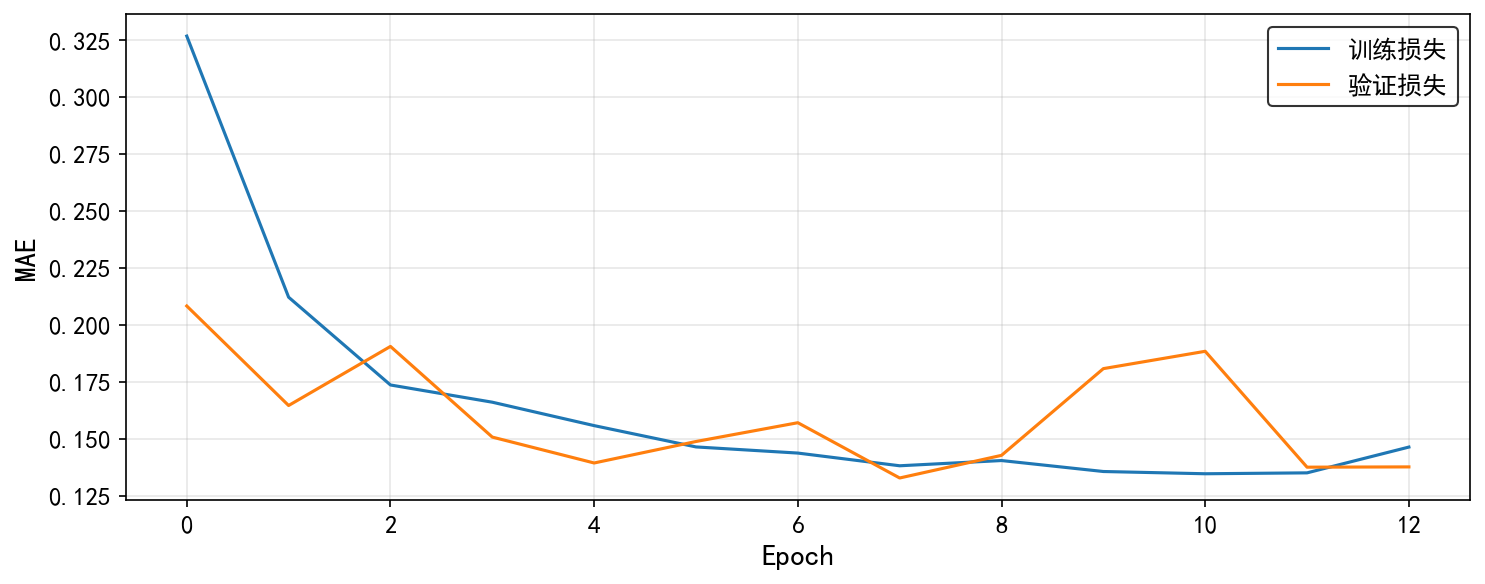

  [2/3] 目标域训练
  最佳 epoch: 19, val_loss: 0.281130


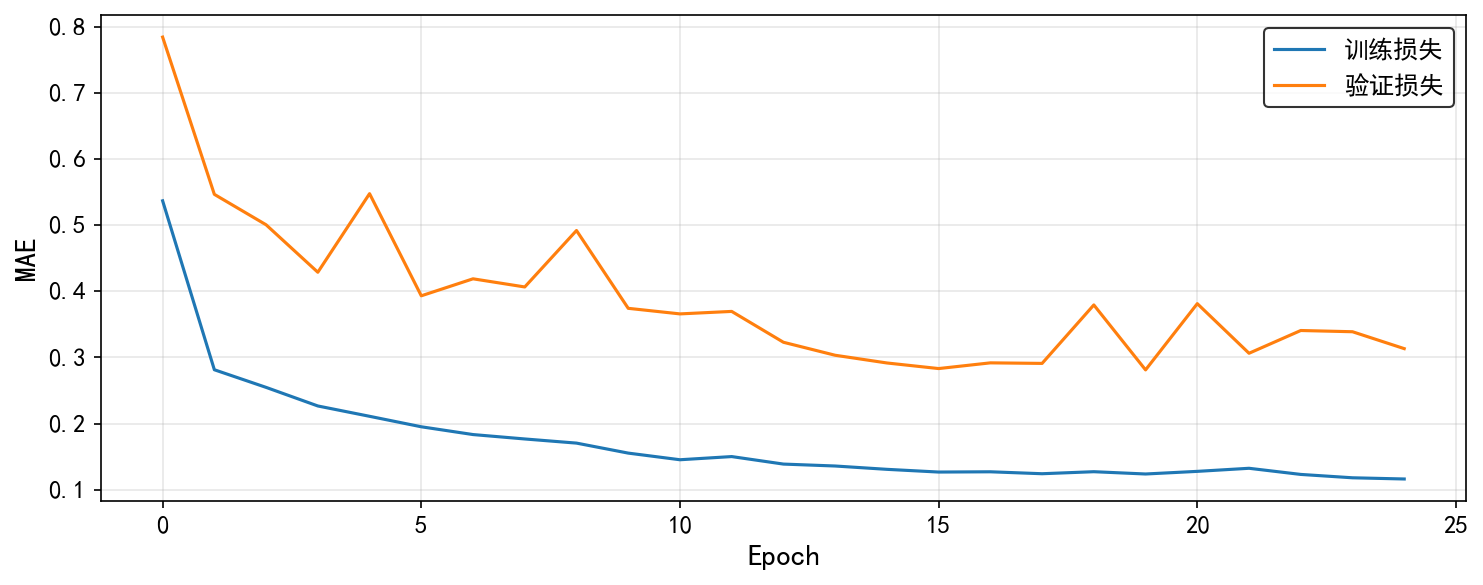

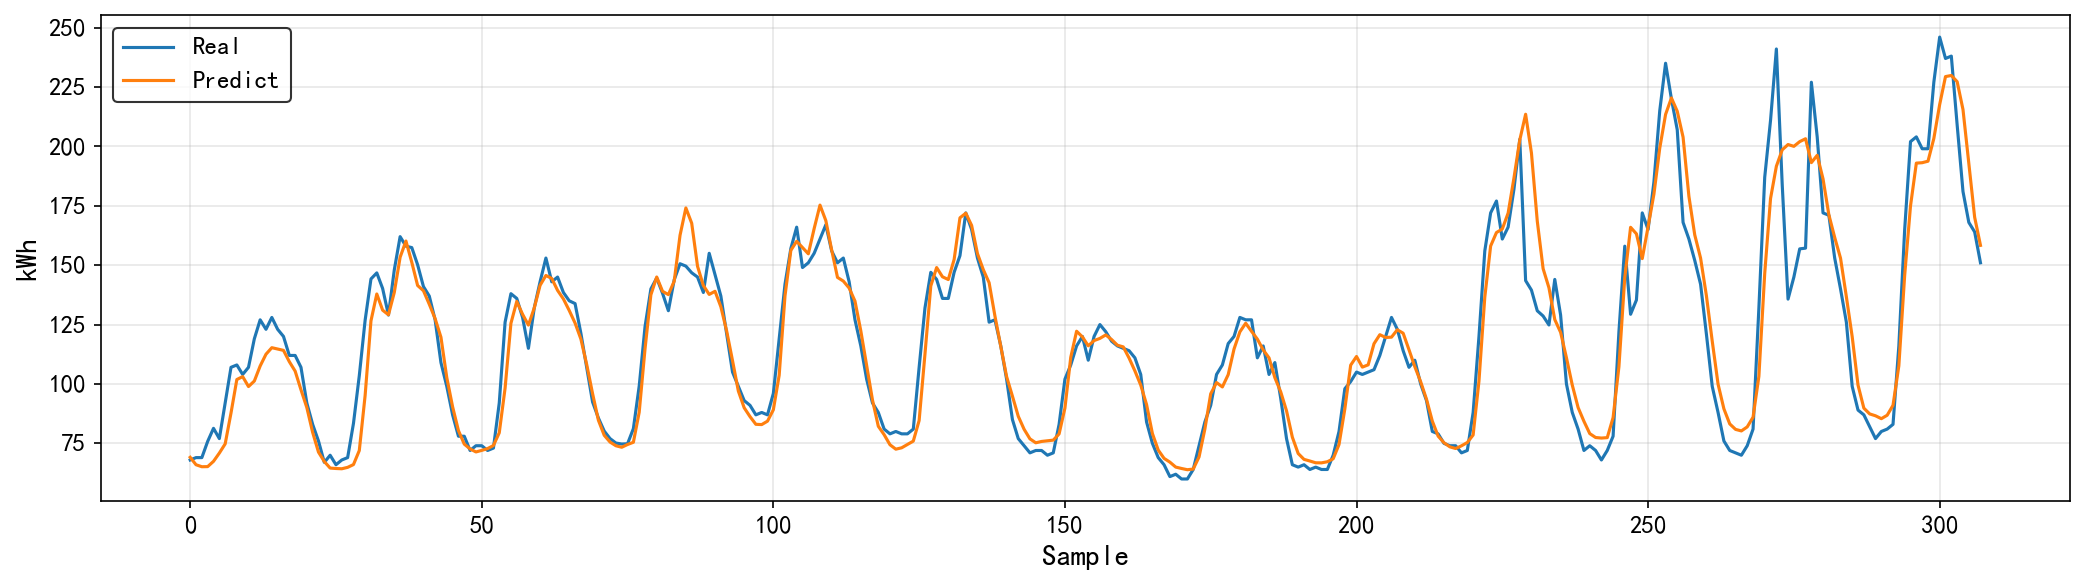

  [3/3] 全层微调
  最佳 epoch: 13, val_loss: 0.190914


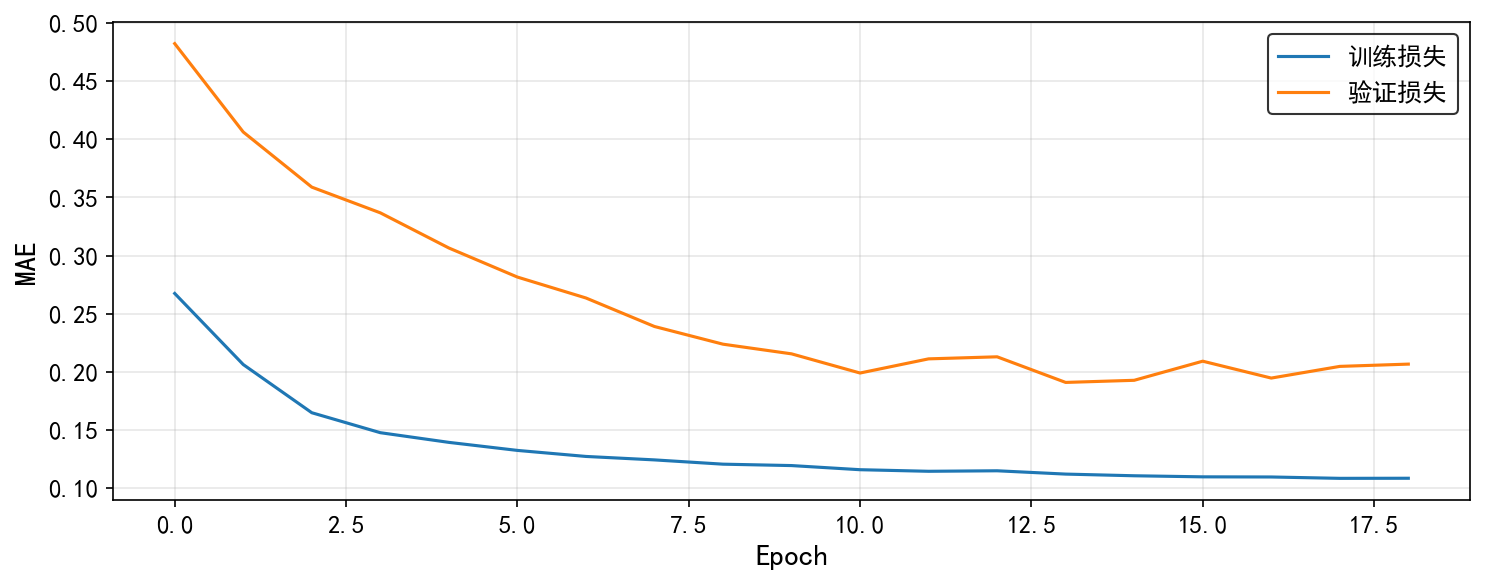

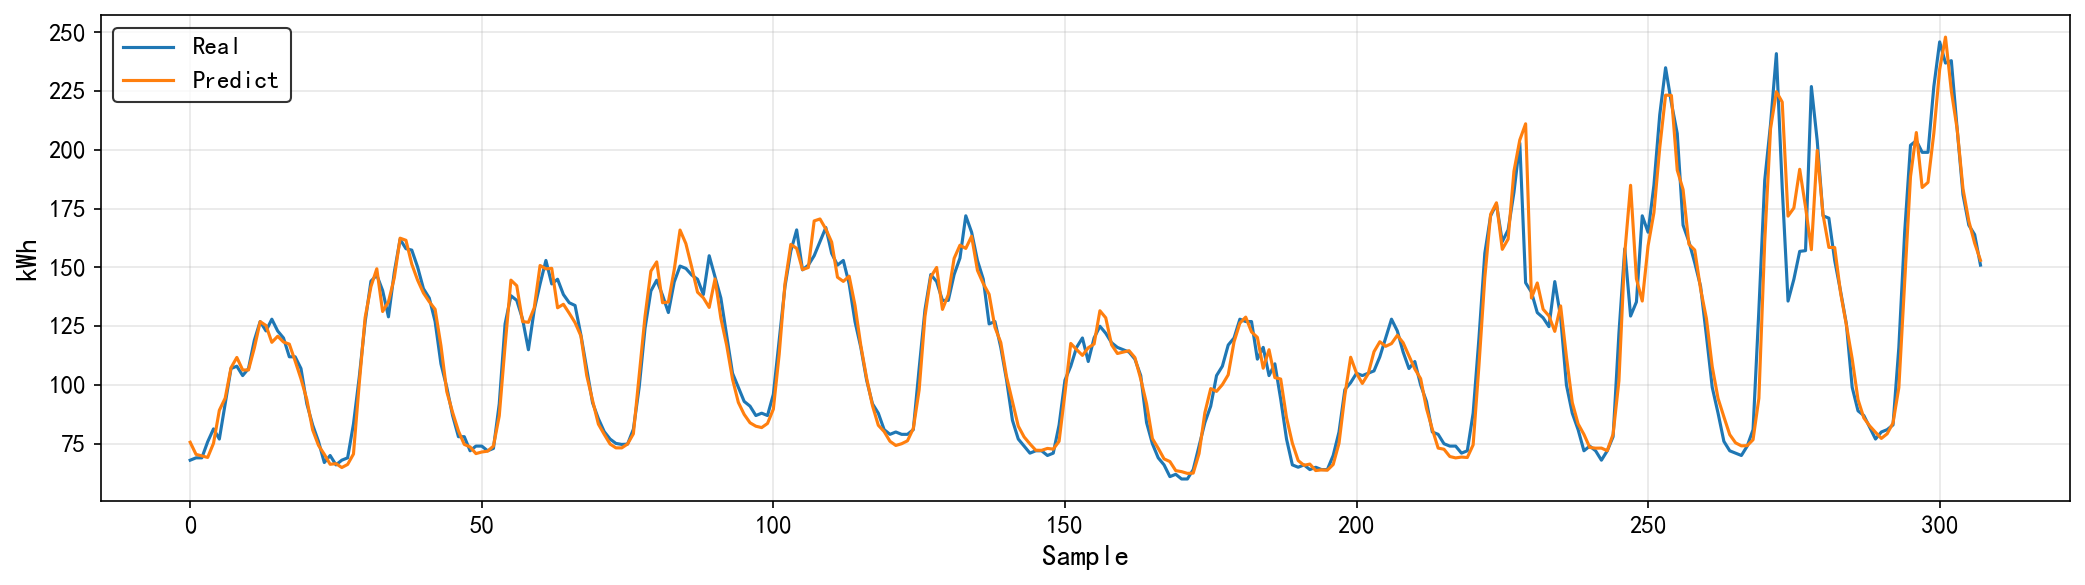


>> HORIZON = 3

  源域训练序列: (6918, 24, 45) -> y: (6918, 3)
  目标域测试序列: (306, 24, 45) -> y: (306, 3)
  [1/3] 源域训练
  最佳 epoch: 1, val_loss: 0.182137


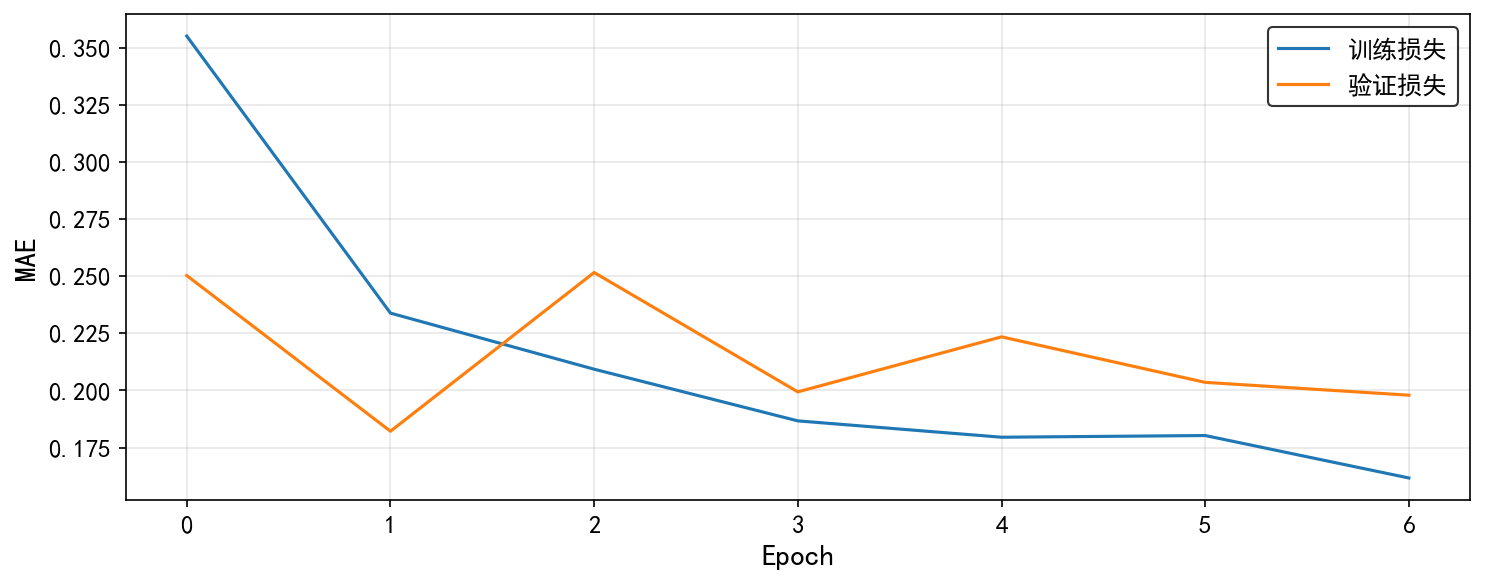

  [2/3] 目标域训练
  最佳 epoch: 9, val_loss: 0.386523


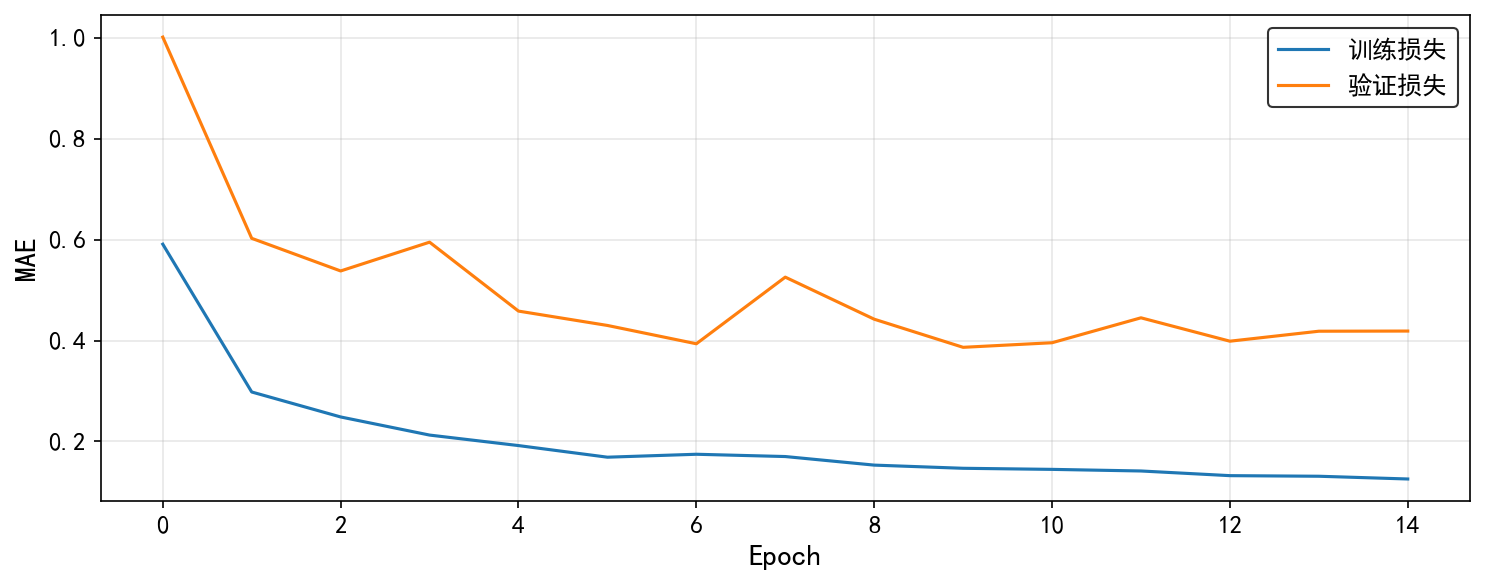

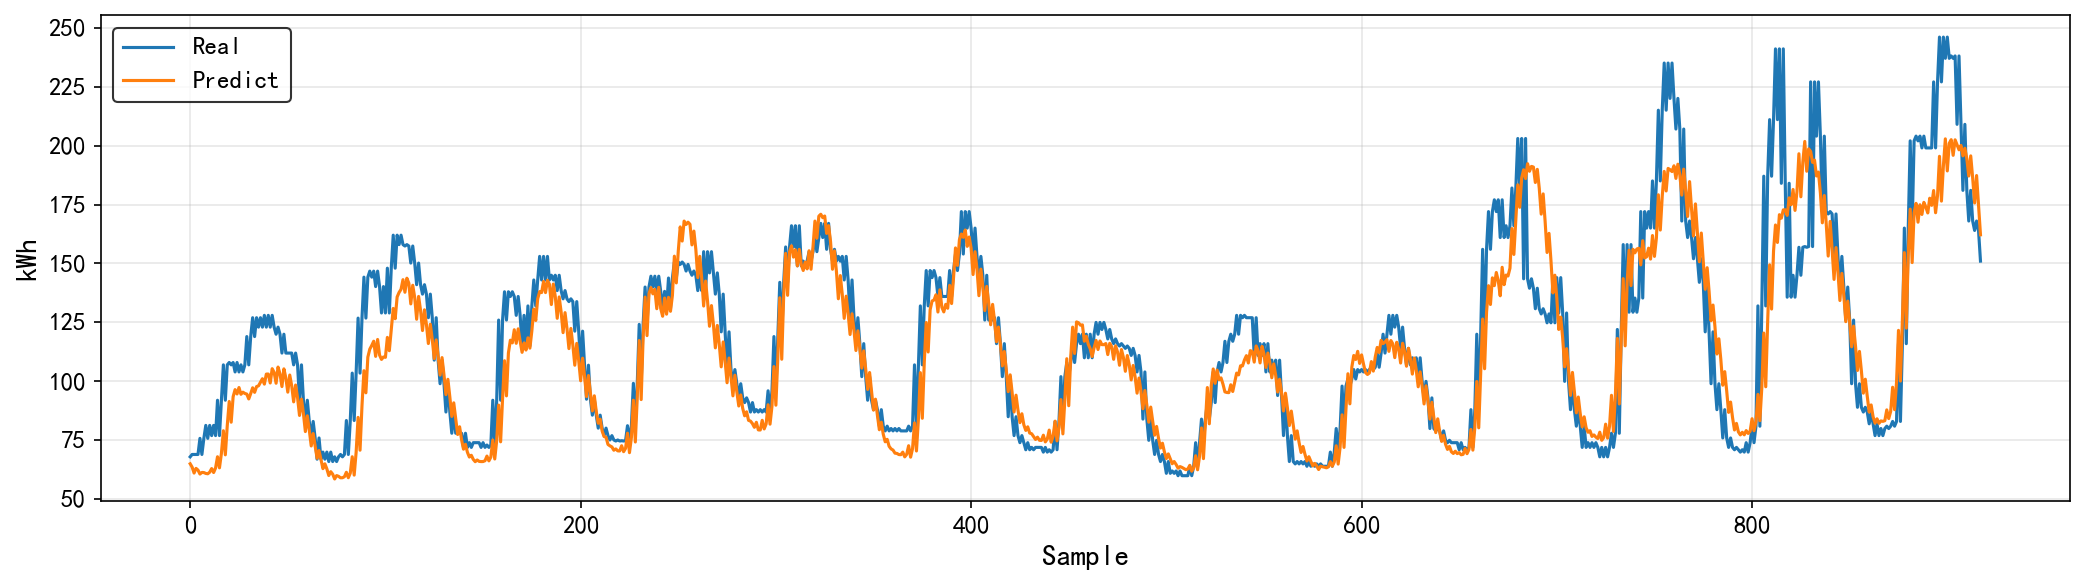

  [3/3] 全层微调
  最佳 epoch: 23, val_loss: 0.328506


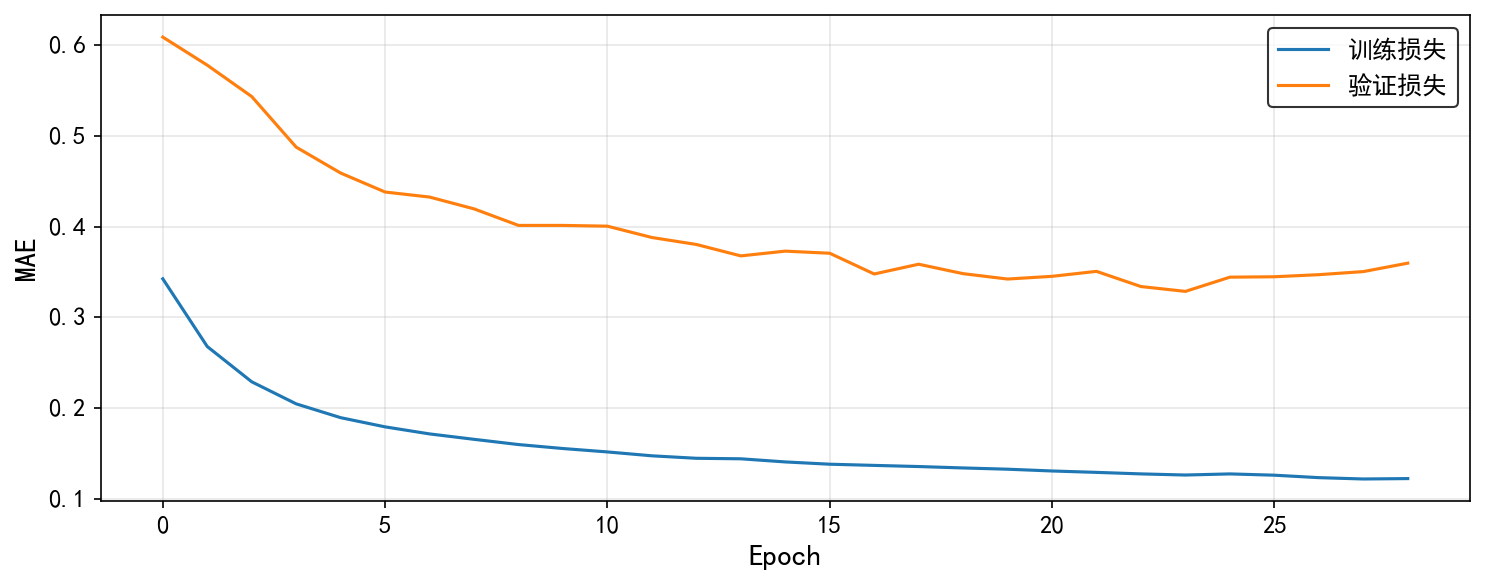

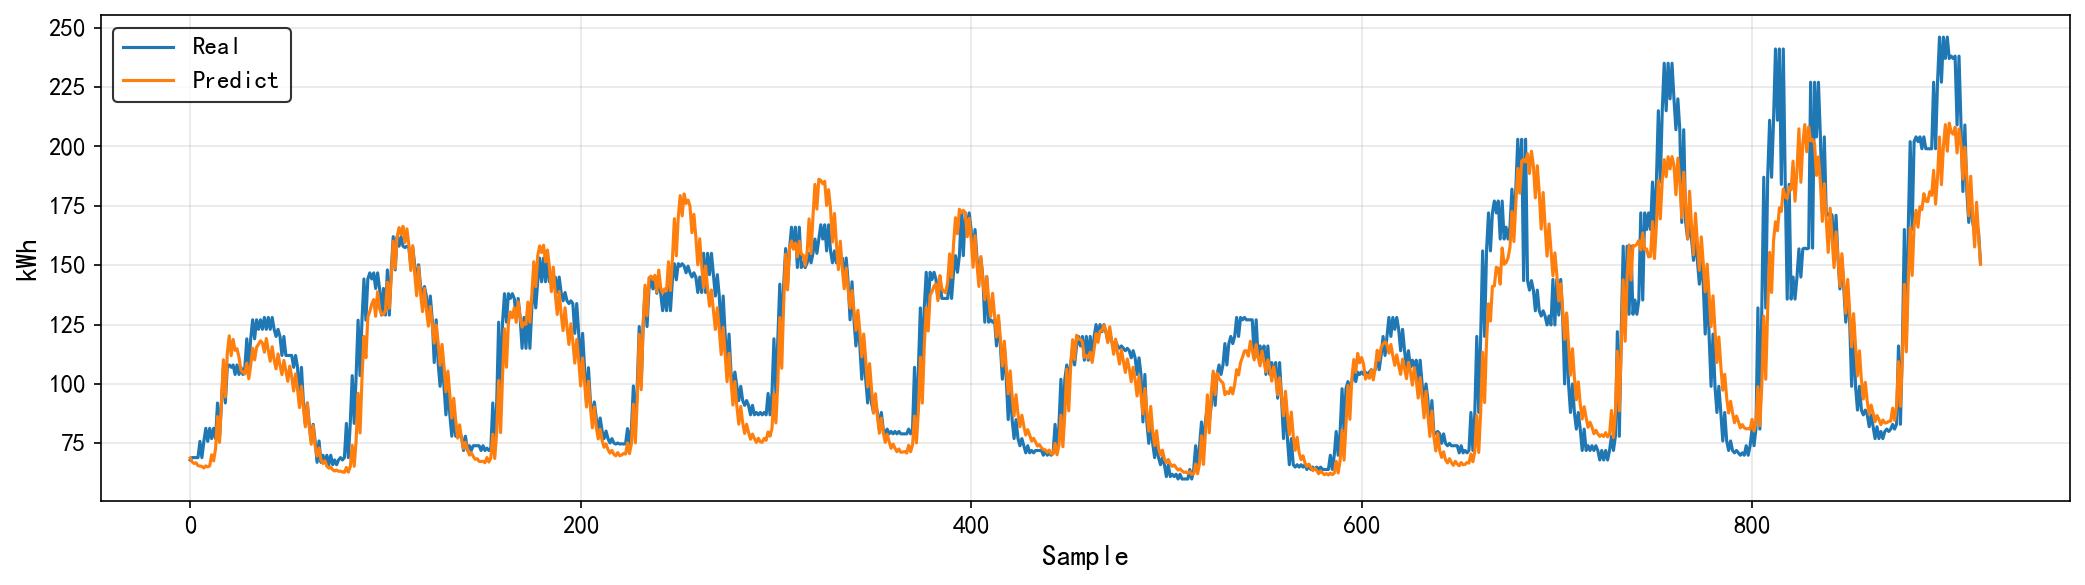


>> HORIZON = 6

  源域训练序列: (6915, 24, 45) -> y: (6915, 6)
  目标域测试序列: (303, 24, 45) -> y: (303, 6)
  [1/3] 源域训练
  最佳 epoch: 2, val_loss: 0.183254


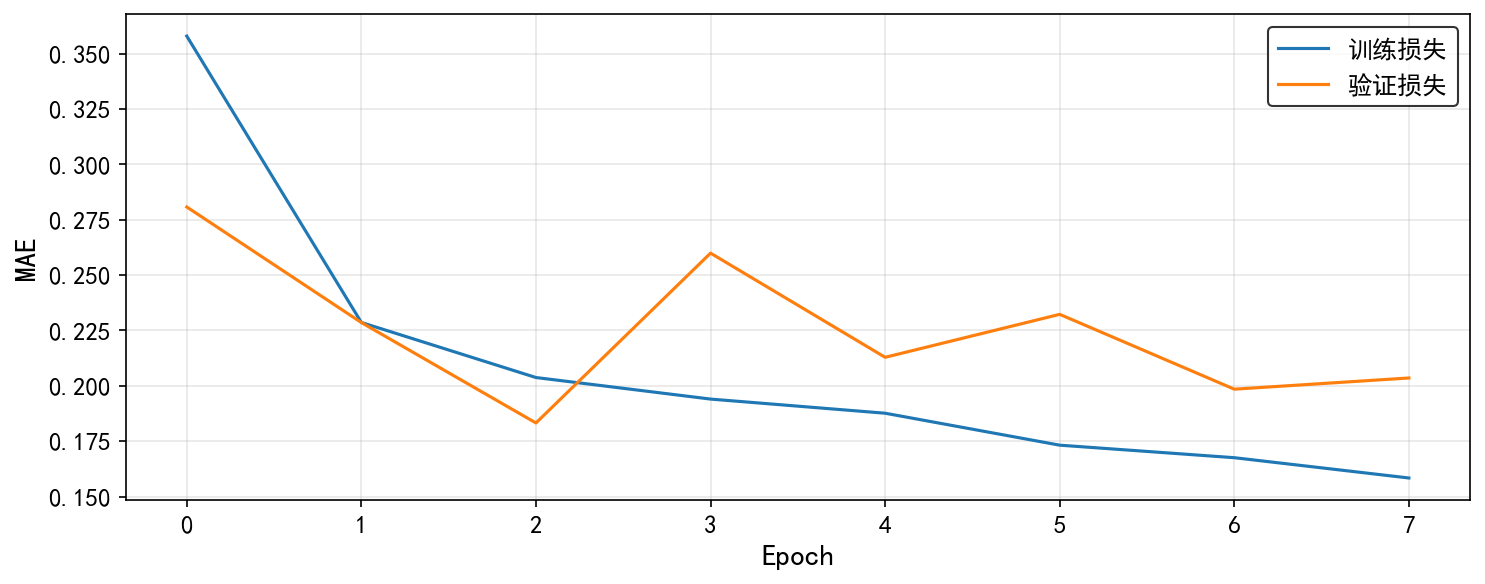

  [2/3] 目标域训练
  最佳 epoch: 8, val_loss: 0.423398


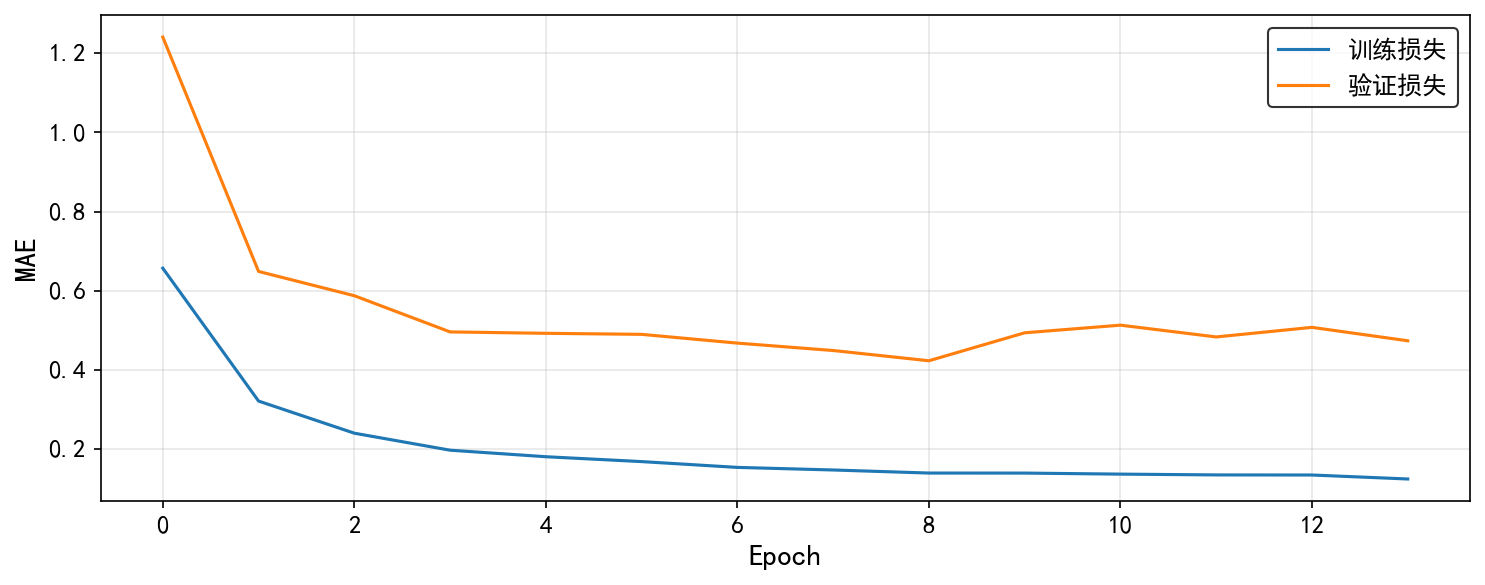

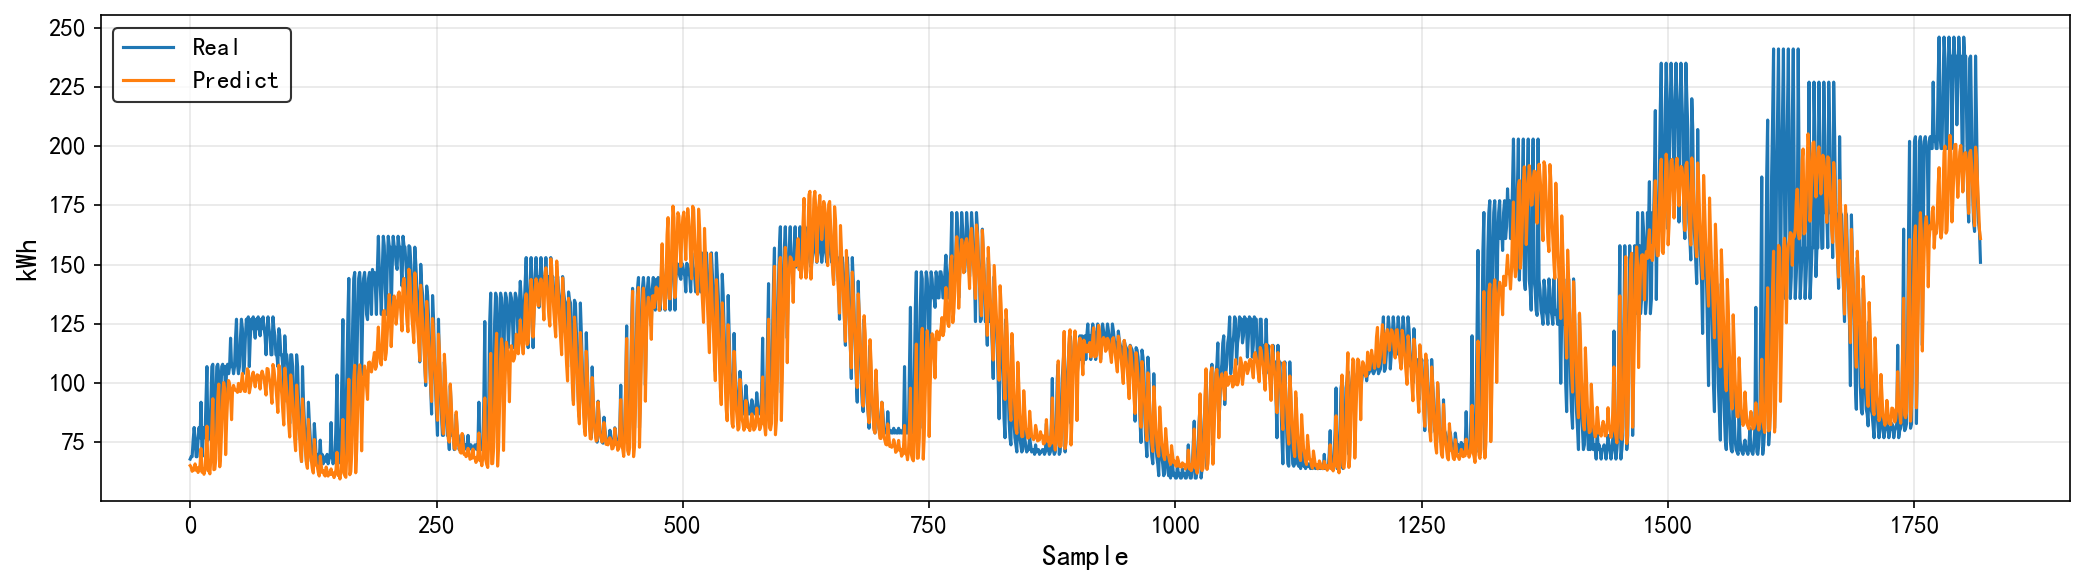

  [3/3] 全层微调
  最佳 epoch: 13, val_loss: 0.354896


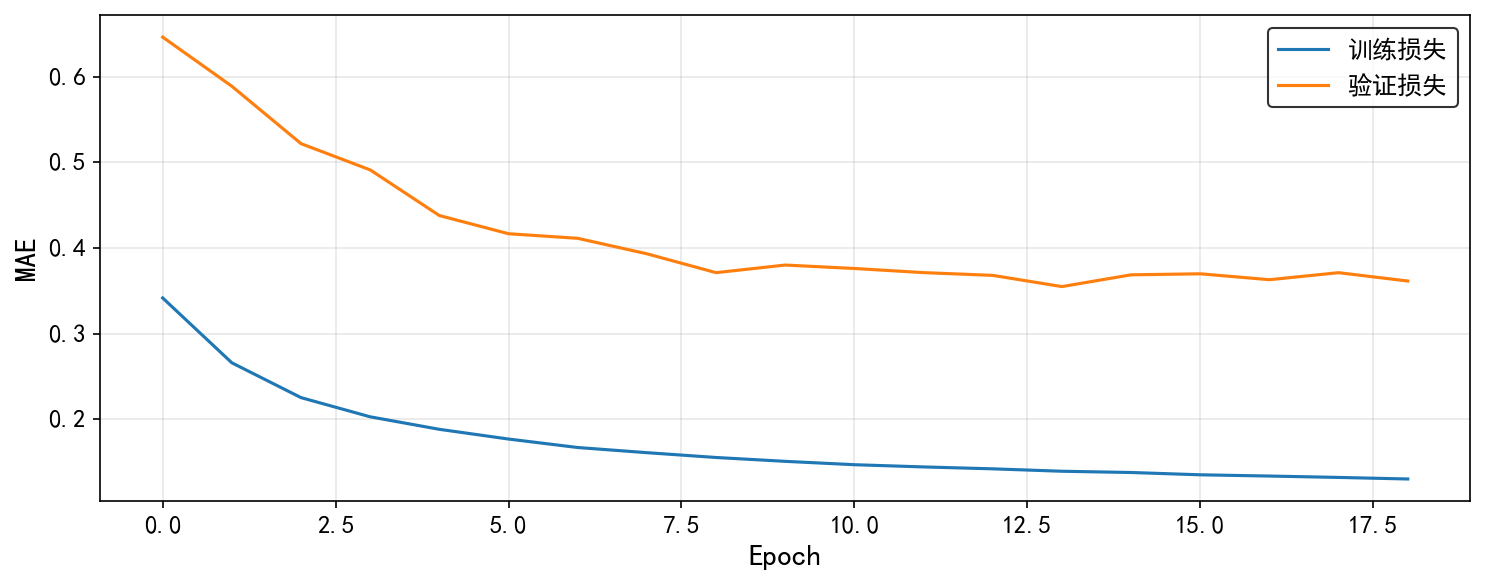

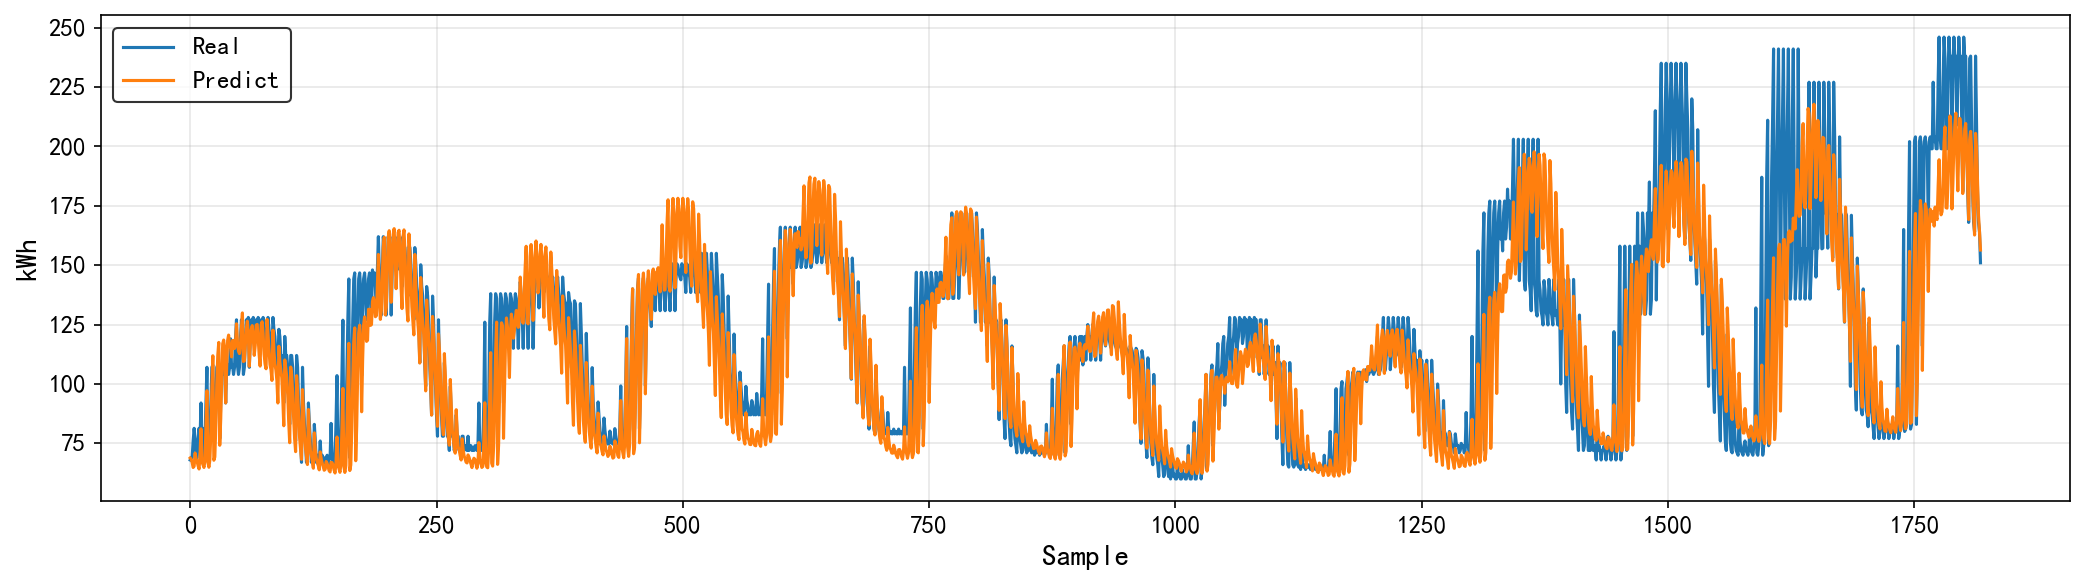

In [3]:
all_results = {}

# 清理上次运行遗留的多步源域权重，避免旧 horizon 权重继续保留
for old_source_model in MODEL_DIR.glob('multistep_source_*.pt'):
    if old_source_model.is_file():
        old_source_model.unlink()

for horizon in HORIZON_LIST:
    print(f"\n>> HORIZON = {horizon}\n")

    # 构造当前 horizon 的序列
    X_source_train, y_source_train = create_sequences(source_train_df, FEATURE_COLS, TARGET_COL, LOOKBACK, horizon)
    X_source_val, y_source_val = create_sequences(source_val_df, FEATURE_COLS, TARGET_COL, LOOKBACK, horizon)
    X_target_train, y_target_train = create_sequences(target_train_df, FEATURE_COLS, TARGET_COL, LOOKBACK, horizon)
    X_target_val, y_target_val = create_sequences(target_val_df, FEATURE_COLS, TARGET_COL, LOOKBACK, horizon)
    X_target_test, y_target_test = create_sequences(target_test_df, FEATURE_COLS, TARGET_COL, LOOKBACK, horizon)

    torch_datasets = {
        'source_train': LoadDataset(X_source_train, y_source_train),
        'source_val': LoadDataset(X_source_val, y_source_val),
        'target_train': LoadDataset(X_target_train, y_target_train),
        'target_val': LoadDataset(X_target_val, y_target_val),
        'target_test': LoadDataset(X_target_test, y_target_test),
    }

    print(f"  源域训练序列: {X_source_train.shape} -> y: {y_source_train.shape}")
    print(f"  目标域测试序列: {X_target_test.shape} -> y: {y_target_test.shape}")

    # ---- 1. 源域训练 ----
    print("  [1/3] 源域训练")
    set_seed(SEED)
    source_train_loader = DataLoader(
        torch_datasets['source_train'],
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    source_val_loader = DataLoader(torch_datasets['source_val'], batch_size=BATCH_SIZE, shuffle=False)
    source_model = LSTMPredictor(input_size=input_size, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, horizon=horizon).to(device)
    optimizer = torch.optim.Adam(source_model.parameters(), lr=1e-3, weight_decay=1e-4)
    lr_scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=4, min_lr=1e-5)
    early_stopping = EarlyStopping(patience=5, restore_best_weights=True)
    source_train_losses, source_val_losses, source_info = fit_model(
        source_model, source_train_loader, source_val_loader, optimizer, lr_scheduler, early_stopping
    )
    print(f"  最佳 epoch: {source_info['best_epoch']}, val_loss: {source_info['best_loss']:.6f}")
    plot_training_history(
        source_train_losses,
        source_val_losses,
        title=f'H={horizon} 源域训练 Loss',
    )
    source_state = {k: v.detach().cpu().clone() for k, v in source_model.state_dict().items()}
    torch.save(source_state, MODEL_DIR / f'multistep_source_h{horizon}.pt')

    # ---- 2. 目标域训练 ----
    print("  [2/3] 目标域训练")
    set_seed(SEED)
    target_train_loader = DataLoader(
        torch_datasets['target_train'],
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    target_val_loader = DataLoader(torch_datasets['target_val'], batch_size=BATCH_SIZE, shuffle=False)
    target_test_loader = DataLoader(torch_datasets['target_test'], batch_size=BATCH_SIZE, shuffle=False)
    target_model = LSTMPredictor(input_size=input_size, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, horizon=horizon).to(device)
    optimizer = torch.optim.Adam(target_model.parameters(), lr=1e-3, weight_decay=1e-4)
    lr_scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=4, min_lr=1e-5)
    early_stopping = EarlyStopping(patience=5, restore_best_weights=True)
    target_train_losses, target_val_losses, target_info = fit_model(
        target_model, target_train_loader, target_val_loader, optimizer, lr_scheduler, early_stopping
    )
    print(f"  最佳 epoch: {target_info['best_epoch']}, val_loss: {target_info['best_loss']:.6f}")
    plot_training_history(
        target_train_losses,
        target_val_losses,
        title=f'H={horizon} 目标域训练 Loss',
    )

    y_pred_target = predict(target_model, target_test_loader, device)
    target_train_overall = evaluate(y_target_test, y_pred_target, target_scaler)
    target_train_per_step = evaluate_per_step(y_target_test, y_pred_target, target_scaler)
    plot_predictions(
        y_target_test,
        y_pred_target,
        title=f'H={horizon} 目标域训练预测结果',
        scaler=target_scaler,
    )

    # ---- 3. 全层微调 ----
    print("  [3/3] 全层微调")
    set_seed(SEED)
    fine_tune_train_loader = DataLoader(
        torch_datasets['target_train'],
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    fine_tune_val_loader = DataLoader(torch_datasets['target_val'], batch_size=BATCH_SIZE, shuffle=False)
    fine_tune_test_loader = DataLoader(torch_datasets['target_test'], batch_size=BATCH_SIZE, shuffle=False)
    fine_tune_model = LSTMPredictor(input_size=input_size, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, horizon=horizon).to(device)
    fine_tune_model.load_state_dict(source_state)
    optimizer = torch.optim.Adam(fine_tune_model.parameters(), lr=1e-4, weight_decay=1e-4)
    lr_scheduler = ReduceLROnPlateau(optimizer, factor=0.5, patience=4, min_lr=1e-6)
    early_stopping = EarlyStopping(patience=5, restore_best_weights=True)
    fine_tune_train_losses, fine_tune_val_losses, fine_tune_info = fit_model(
        fine_tune_model, fine_tune_train_loader, fine_tune_val_loader, optimizer, lr_scheduler, early_stopping
    )
    print(f"  最佳 epoch: {fine_tune_info['best_epoch']}, val_loss: {fine_tune_info['best_loss']:.6f}")
    plot_training_history(
        fine_tune_train_losses,
        fine_tune_val_losses,
        title=f'H={horizon} 全层微调 Loss',
    )

    y_pred_fine_tune = predict(fine_tune_model, fine_tune_test_loader, device)
    full_fine_tune_overall = evaluate(y_target_test, y_pred_fine_tune, target_scaler)
    full_fine_tune_per_step = evaluate_per_step(y_target_test, y_pred_fine_tune, target_scaler)
    plot_predictions(
        y_target_test,
        y_pred_fine_tune,
        title=f'H={horizon} 全层微调预测结果',
        scaler=target_scaler,
    )

    all_results[horizon] = {
        'target_train_overall': target_train_overall,
        'target_train_per_step': target_train_per_step,
        'full_fine_tune_overall': full_fine_tune_overall,
        'full_fine_tune_per_step': full_fine_tune_per_step,
    }


## 结果分析

本节只输出论文 5.5 节需要的两类证据：整体指标对比和逐步误差变化。整体指标用于回答不同预测步长下全层微调是否优于目标域训练；逐步误差变化用于观察多步模型在未来各步上的误差累积或波动。

### 1. 整体指标对比

整体指标将测试集中所有预测步合并后计算，适合比较 `HORIZON=1、3、6` 下目标域训练与全层微调的总体预测性能。


In [4]:
# 整体指标对比表
overall_rows = []
for h in HORIZON_LIST:
    r = all_results[h]
    for strategy, metrics in [('目标域训练', r['target_train_overall']), ('全层微调', r['full_fine_tune_overall'])]:
        overall_rows.append({'HORIZON': h, '策略': strategy, **metrics})

overall_df = pd.DataFrame(overall_rows)
print('整体指标对比（所有预测步合并计算）')
print(overall_df.to_string(index=False, float_format='%.4f'))


整体指标对比（所有预测步合并计算）
 HORIZON    策略     MAE    RMSE  CV-RMSE    MAPE     R2
       1 目标域训练  9.0863 13.8608  11.7296  7.4880 0.8833
       1  全层微调  6.2431 10.5001   8.8857  5.0938 0.9330
       3 目标域训练 12.2958 17.0423  14.4169  9.7956 0.8234
       3  全层微调 10.8160 15.5752  13.1758  8.7730 0.8525
       6 目标域训练 13.0773 18.3225  15.5051 10.4313 0.7946
       6  全层微调 11.5425 16.9837  14.3721  9.1530 0.8235



### 2. 逐步误差变化

逐步误差按未来第 `step` 步分别计算。`H=1` 的结果保留在表格和 CSV 中，但不输出逐步误差图。为便于比较迁移前后在同一预测步长下的变化，`H=3、6` 每个 `HORIZON` 单独输出一张图；每张图只比较该 `HORIZON` 下的目标域训练和全层微调。生成图片前会清理上次运行遗留的逐步误差变化图，避免旧文件继续保留。


逐步误差结果（按未来预测步分别计算）
 HORIZON    策略  step     MAE    RMSE  CV-RMSE    MAPE     R2
       1 目标域训练     1  9.0863 13.8608  11.7296  7.4880 0.8833
       1  全层微调     1  6.2431 10.5001   8.8857  5.0938 0.9330
       3 目标域训练     1 11.6975 16.2781  13.8052  9.3277 0.8391
       3 目标域训练     2 12.1923 16.9226  14.3138  9.7266 0.8260
       3 目标域训练     3 12.9977 17.8878  15.0960 10.3324 0.8050
       3  全层微调     1 10.0972 14.6708  12.4421  8.1819 0.8693
       3  全层微调     2 10.8887 15.6537  13.2405  8.8458 0.8511
       3  全层微调     3 11.4621 16.3550  13.8024  9.2912 0.8370
       6 目标域训练     1 12.1386 17.2613  14.7233  9.7767 0.8154
       6 目标域训练     2 12.6747 17.8953  15.2037 10.2048 0.8039
       6 目标域训练     3 13.4460 18.7937  15.9170 10.7033 0.7844
       6 目标域训练     4 13.2719 18.5506  15.6678 10.5641 0.7900
       6 目标域训练     5 12.9510 18.1000  15.2497 10.2900 0.8002
       6 目标域训练     6 13.9816 19.2653  16.2001 11.0490 0.7735
       6  全层微调     1 10.1843 15.1074  12.8861  8.0558 0.8586
     

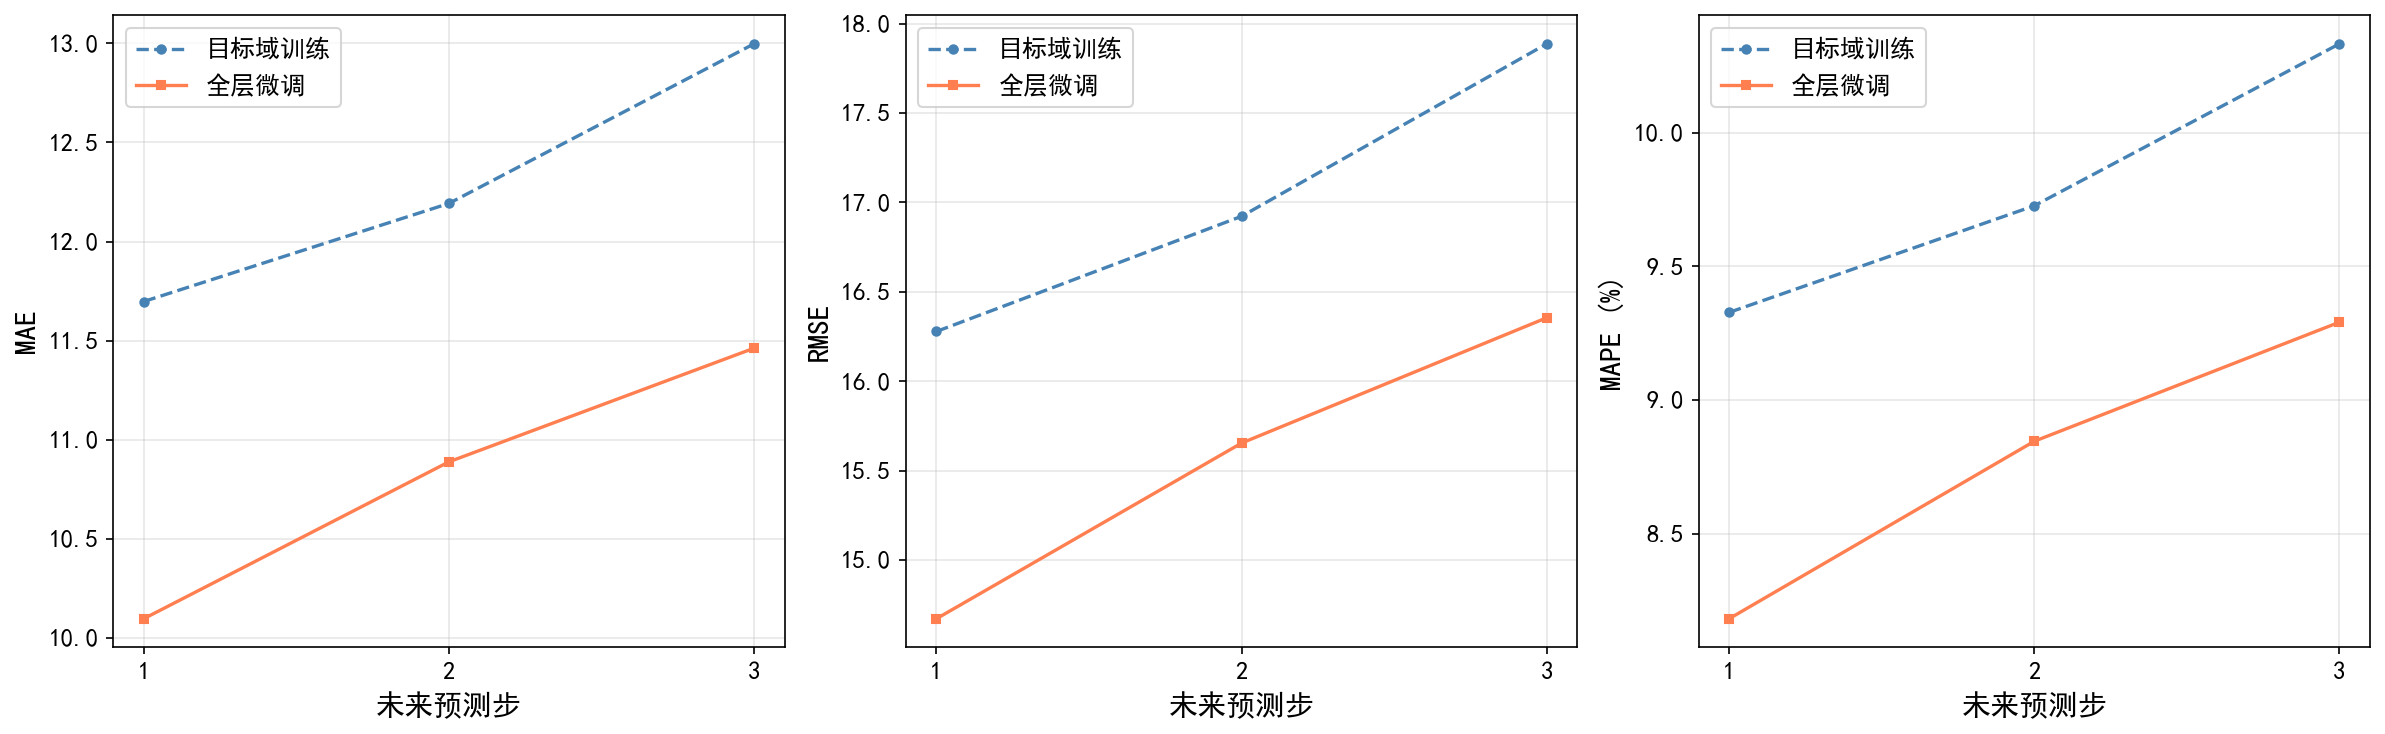

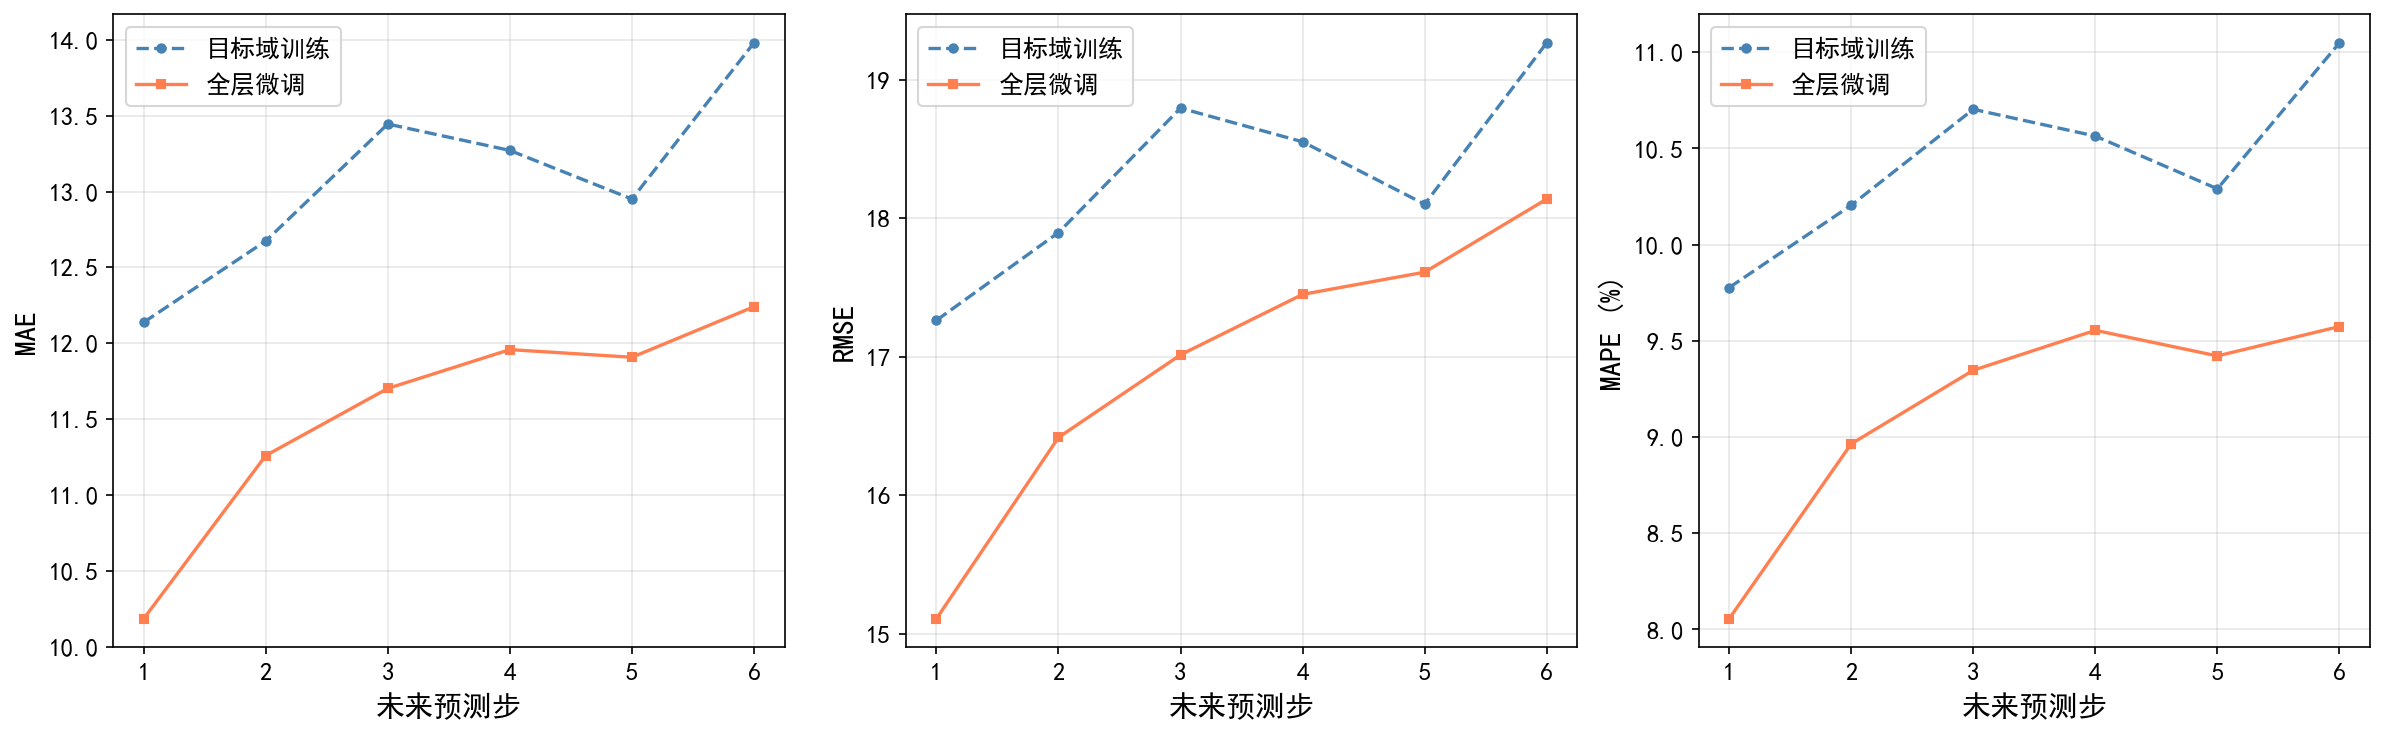

In [5]:
# 逐步误差结果表与按 HORIZON 独立输出的变化曲线
per_step_all = []
for h in HORIZON_LIST:
    for strategy, key in [('目标域训练', 'target_train_per_step'), ('全层微调', 'full_fine_tune_per_step')]:
        df = all_results[h][key].copy()
        df.insert(0, '策略', strategy)
        df.insert(0, 'HORIZON', h)
        per_step_all.append(df)

per_step_all_df = pd.concat(per_step_all, ignore_index=True)
print('逐步误差结果（按未来预测步分别计算）')
print(per_step_all_df.to_string(index=False, float_format='%.4f'))

metrics_to_plot = ['MAE', 'RMSE', 'MAPE']
strategy_styles = {
    '目标域训练': {'color': 'steelblue', 'marker': 'o', 'linestyle': '--', 'label': '目标域训练'},
    '全层微调': {'color': 'coral', 'marker': 's', 'linestyle': '-', 'label': '全层微调'},
}
per_step_figure_paths = []

# 清理上次运行遗留的逐步误差变化图，避免旧 HORIZON 图片继续保留
for old_step_plot in FIGURES_DIR.glob('逐步误差变化_H*.png'):
    step_h = old_step_plot.stem.removeprefix('逐步误差变化_H')
    if step_h.isdigit() and old_step_plot.is_file():
        old_step_plot.unlink()

for h in [item for item in HORIZON_LIST if item > 1]:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    horizon_df = per_step_all_df[per_step_all_df['HORIZON'] == h]

    for ax, metric in zip(axes, metrics_to_plot):
        for strategy, style in strategy_styles.items():
            plot_df = horizon_df[horizon_df['策略'] == strategy].sort_values('step')
            ax.plot(
                plot_df['step'],
                plot_df[metric],
                color=style['color'],
                linestyle=style['linestyle'],
                marker=style['marker'],
                markersize=4,
                linewidth=1.6,
                label=style['label'],
            )

        ax.set_xlabel('未来预测步', fontsize=14)
        ax.set_ylabel(metric if metric != 'MAPE' else 'MAPE (%)', fontsize=14)
        ax.set_xticks(range(1, h + 1))
        ax.tick_params(axis='both', labelsize=12)
        ax.legend(fontsize=12)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    figure_path = FIGURES_DIR / f'逐步误差变化_H{h}.png'
    plt.savefig(figure_path, dpi=150, bbox_inches='tight')
    per_step_figure_paths.append(figure_path)
    plt.show()


### 3. 保存结果

保存整体指标表和逐步误差表，供论文结果表和各预测步长的逐步误差变化曲线复用。


In [6]:
# 保存整体指标与逐步误差结果
overall_df.to_csv(BASE_DIR / 'multistep_overall_metrics.csv', index=False, encoding='utf-8-sig')
per_step_all_df.to_csv(BASE_DIR / 'multistep_per_step_results.csv', index=False, encoding='utf-8-sig')

print(f"整体指标对比已保存: {BASE_DIR / 'multistep_overall_metrics.csv'}")
print(f"逐步误差变化结果已保存: {BASE_DIR / 'multistep_per_step_results.csv'}")
for figure_path in per_step_figure_paths:
    print(f"逐步误差变化图已保存: {figure_path}")


整体指标对比已保存: data\multistep_overall_metrics.csv
逐步误差变化结果已保存: data\multistep_per_step_results.csv
逐步误差变化图已保存: data\figures\逐步误差变化_H3.png
逐步误差变化图已保存: data\figures\逐步误差变化_H6.png
